In [1]:
import pandas as pd
import numpy as np
import os
import brightway2 as bw

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker

In [2]:
bw.projects.set_current('Prospective LCA v5')

In [3]:
methodsDict = {'climate change':                ('IPCC 2013', 'climate change', 'GWP 100a, incl. H and bio CO2'),
            'acidification':                    ('EF v3.0 no LT', 'acidification no LT', 'accumulated exceedance (ae) no LT'),
            'eutrophication freshwater':        ('EF v3.0 no LT', 'eutrophication: freshwater no LT', 'fraction of nutrients reaching freshwater end compartment (P) no LT'),
            'eutrophication marine':            ('EF v3.0 no LT', 'eutrophication: marine no LT', 'fraction of nutrients reaching marine end compartment (N) no LT'),
            'eutrophication terrestrial':       ('EF v3.0 no LT', 'eutrophication: terrestrial no LT', 'accumulated exceedance (AE)  no LT'),
            'photochemical ozone formation':    ('EF v3.0 no LT', 'photochemical ozone formation: human health no LT', 'tropospheric ozone concentration increase no LT'),
            'particulate matter':               ('EF v3.0 no LT', 'particulate matter formation no LT', 'impact on human health no LT'),
            'ozone depletion':                  ('EF v3.0 no LT', 'ozone depletion no LT', 'ozone depletion potential (ODP)  no LT'),
            'ecotoxicity freshwater':           ('EF v3.0 no LT', 'ecotoxicity: freshwater no LT', 'comparative toxic unit for ecosystems (CTUe)  no LT'),
            'human toxicity carcinogenic':      ('EF v3.0 no LT', 'human toxicity: carcinogenic no LT', 'comparative toxic unit for human (CTUh)  no LT'),
            'human toxicity non-carcinogenic':  ('EF v3.0 no LT', 'human toxicity: non-carcinogenic no LT', 'comparative toxic unit for human (CTUh)  no LT'),
            'ionising radiation':               ('EF v3.0 no LT', 'ionising radiation: human health no LT', 'human exposure efficiency relative to u235 no LT'), 
            'resource use fossils':             ('EF v3.0 no LT', 'energy resources: non-renewable no LT', 'abiotic depletion potential (ADP): fossil fuels no LT'),
            'resource use mineral and metals':  ('EF v3.0 no LT', 'material resources: metals/minerals no LT', 'abiotic depletion potential (ADP): elements (ultimate reserves) no LT'),
            'land use':                         ('EF v3.0 no LT', 'land use no LT', 'soil quality index no LT'),
            'water use':                        ('EF v3.0 no LT', 'water use no LT', 'user deprivation potential (deprivation-weighted water consumption) no LT')
            }    

In [4]:
methodsDictSorted = {key : methodsDict[key] for key in sorted(methodsDict)}

In [5]:
units = []
for key, values in methodsDictSorted.items():
    method = bw.methods.get(values)
    units.append(method['unit'])
units

['mol H+-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg PO4-Eq',
 'kg N-Eq',
 'mol N-Eq',
 'CTUh',
 'CTUh',
 'kBq U235-Eq',
 'dimensionless',
 'kg CFC-11-Eq',
 'disease incidence',
 'kg NMVOC-Eq',
 'MJ, net calorific value',
 'kg Sb-Eq',
 'm3 world eq. deprived']

In [6]:
for i in range(0, len(units)):
    units[i] = units[i].replace('Eq', 'eq')
units

['mol H+-eq',
 'kg CO2-eq',
 'CTUe',
 'kg PO4-eq',
 'kg N-eq',
 'mol N-eq',
 'CTUh',
 'CTUh',
 'kBq U235-eq',
 'dimensionless',
 'kg CFC-11-eq',
 'disease incidence',
 'kg NMVOC-eq',
 'MJ, net calorific value',
 'kg Sb-eq',
 'm3 world eq. deprived']

In [7]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [8]:
hydrogenResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Hydrogen')
hydrogenResults = {}
impactCategories = []
for fileName in os.listdir(hydrogenResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(hydrogenResultsPath, fileName)
        impactCategory = fileName.replace('hydrogen ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    hydrogenResults[impactCategory] = totalImpactCatDF

for dfName, df in hydrogenResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    hydrogenResults[dfName] = filteredDF

In [9]:
ammoniaResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Ammonia')
ammoniaResults = {}
impactCategories = []
for fileName in os.listdir(ammoniaResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(ammoniaResultsPath, fileName)
        impactCategory = fileName.replace('ammonia ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    ammoniaResults[impactCategory] = totalImpactCatDF

for dfName, df in ammoniaResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    ammoniaResults[dfName] = filteredDF

In [10]:
methanolResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Methanol')
methanolResults = {}
impactCategories = []
for fileName in os.listdir(methanolResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(methanolResultsPath, fileName)
        impactCategory = fileName.replace('methanol ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    methanolResults[impactCategory] = totalImpactCatDF

for dfName, df in methanolResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    methanolResults[dfName] = filteredDF

In [11]:
ethyleneResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Ethylene')
ethyleneResults = {}
impactCategories = []
for fileName in os.listdir(ethyleneResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(ethyleneResultsPath, fileName)
        impactCategory = fileName.replace('ethylene ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    ethyleneResults[impactCategory] = totalImpactCatDF

for dfName, df in ethyleneResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    ethyleneResults[dfName] = filteredDF

In [12]:
impactCategories.sort()
impactCategories

['acidification',
 'climate change',
 'ecotoxicity freshwater',
 'eutrophication freshwater',
 'eutrophication marine',
 'eutrophication terrestrial',
 'human toxicity carcinogenic',
 'human toxicity non-carcinogenic',
 'ionising radiation',
 'land use',
 'ozone depletion',
 'particulate matter',
 'photochemical ozone formation',
 'resource use fossils',
 'resource use mineral and metals',
 'water use']

In [13]:
years = ['2020', '2030', '2040', '2050']
alphabets = ['a ', 'b ', 'c ', 'd ', 'e ', 'f ', 'g ', 'h ', 'i ', 'j ', 'k ', 'l ', 'm ', 'n ', 'o ', 'p ']

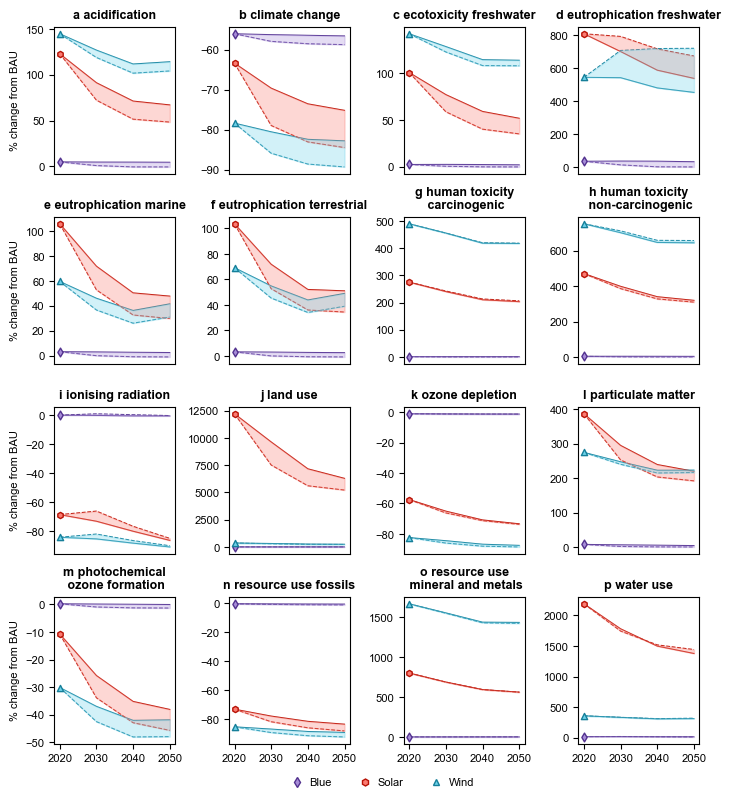

In [14]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    hydrogenResult = hydrogenResults[impactCategories[i]]
    hydrogenResultsRCP6 = hydrogenResult[hydrogenResult['Database'].str.contains('Base')]
    hydrogenBAURCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('solar')]

    hydrogenResultsRCP19 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP19')]
    hydrogenBAURCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('solar')]

    hydrogenBAURCP6 = hydrogenBAURCP6.reset_index(drop=True)
    hydrogenBlueRCP6 = hydrogenBlueRCP6.reset_index(drop=True)
    hydrogenWindRCP6 = hydrogenWindRCP6.reset_index(drop = True)
    hydrogenSolarRCP6 = hydrogenSolarRCP6.reset_index(drop = True)
    blueRCP6 = (hydrogenBlueRCP6['Impact'] - hydrogenBAURCP6['Impact'])/hydrogenBAURCP6['Impact']*100
    windRCP6 = (hydrogenWindRCP6['Impact'] - hydrogenBAURCP6['Impact'])/hydrogenBAURCP6['Impact']*100
    solarRCP6 = (hydrogenSolarRCP6['Impact'] - hydrogenBAURCP6['Impact'])/hydrogenBAURCP6['Impact']*100

    hydrogenBAURCP19 = hydrogenBAURCP19.reset_index(drop=True)
    hydrogenBlueRCP19 = hydrogenBlueRCP19.reset_index(drop=True)
    hydrogenWindRCP19 = hydrogenWindRCP19.reset_index(drop = True)
    hydrogenSolarRCP19 = hydrogenSolarRCP19.reset_index(drop = True)
    blueRCP19 = (hydrogenBlueRCP19['Impact'] - hydrogenBAURCP19['Impact'])/hydrogenBAURCP19['Impact']*100
    windRCP19 = (hydrogenWindRCP19['Impact'] - hydrogenBAURCP19['Impact'])/hydrogenBAURCP19['Impact']*100
    solarRCP19 = (hydrogenSolarRCP19['Impact'] - hydrogenBAURCP19['Impact'])/hydrogenBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen relative image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen relative image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

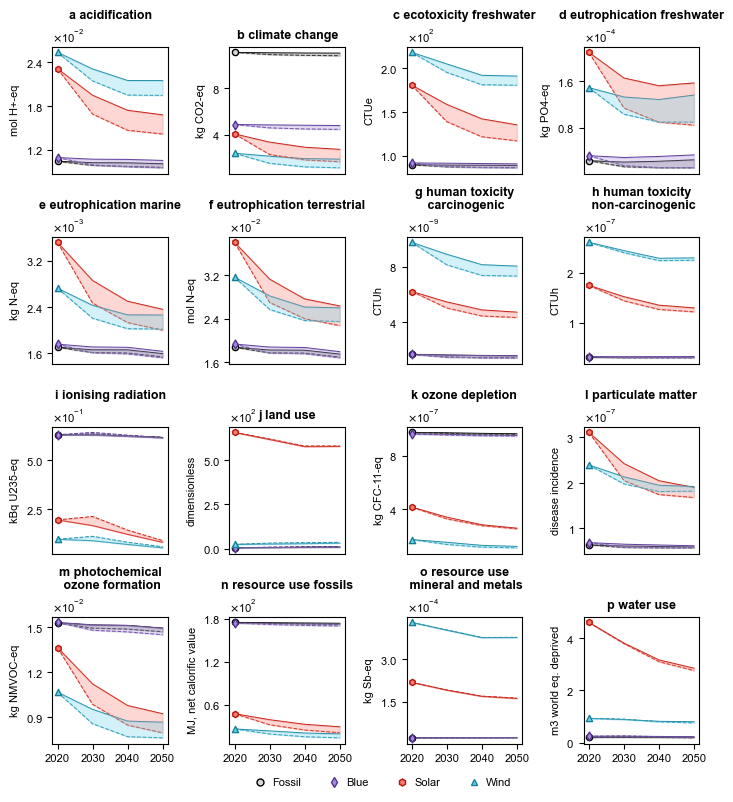

In [15]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    hydrogenResult = hydrogenResults[impactCategories[i]]
    hydrogenResultsRCP6 = hydrogenResult[hydrogenResult['Database'].str.contains('Base')]
    hydrogenBAURCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('solar')]

    hydrogenResultsRCP19 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP19')]
    hydrogenBAURCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('solar')]

    hydrogenBAURCP6 = hydrogenBAURCP6.reset_index(drop=True)
    hydrogenBlueRCP6 = hydrogenBlueRCP6.reset_index(drop=True)
    hydrogenWindRCP6 = hydrogenWindRCP6.reset_index(drop = True)
    hydrogenSolarRCP6 = hydrogenSolarRCP6.reset_index(drop = True)

    hydrogenBAURCP19 = hydrogenBAURCP19.reset_index(drop=True)
    hydrogenBlueRCP19 = hydrogenBlueRCP19.reset_index(drop=True)
    hydrogenWindRCP19 = hydrogenWindRCP19.reset_index(drop = True)
    hydrogenSolarRCP19 = hydrogenSolarRCP19.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, hydrogenBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, hydrogenBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, hydrogenSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, hydrogenWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, hydrogenBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, hydrogenBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, hydrogenSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, hydrogenWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, hydrogenBAURCP6['Impact'], hydrogenBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, hydrogenBlueRCP6['Impact'], hydrogenBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, hydrogenSolarRCP6['Impact'], hydrogenSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, hydrogenWindRCP6['Impact'], hydrogenWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], hydrogenBAURCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], hydrogenBlueRCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], hydrogenSolarRCP6['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], hydrogenWindRCP6['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

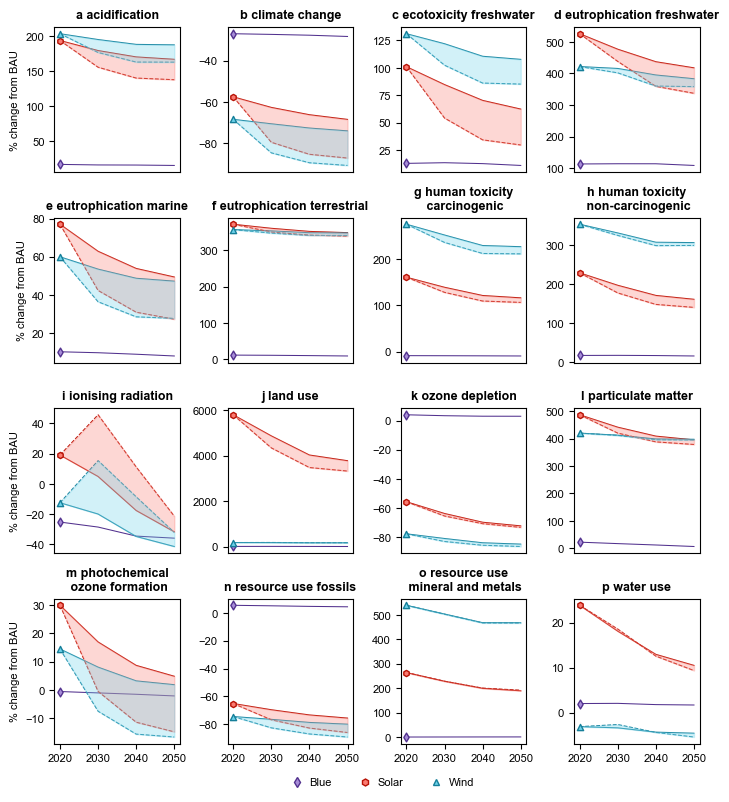

In [16]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ammoniaResult = ammoniaResults[impactCategories[i]]
    ammoniaResultsRCP6 = ammoniaResult[ammoniaResult['Database'].str.contains('Base')]
    ammoniaBAURCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('solar')]

    ammoniaResultsRCP19 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP19')]
    ammoniaBAURCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammoni, blue')]
    ammoniaWindRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('solar')]

    ammoniaBAURCP6 = ammoniaBAURCP6.reset_index(drop=True)
    ammoniaBlueRCP6 = ammoniaBlueRCP6.reset_index(drop=True)
    ammoniaWindRCP6 = ammoniaWindRCP6.reset_index(drop = True)
    ammoniaSolarRCP6 = ammoniaSolarRCP6.reset_index(drop = True)
    blueRCP6 = (ammoniaBlueRCP6['Impact'] - ammoniaBAURCP6['Impact'])/ammoniaBAURCP6['Impact']*100
    windRCP6 = (ammoniaWindRCP6['Impact'] - ammoniaBAURCP6['Impact'])/ammoniaBAURCP6['Impact']*100
    solarRCP6 = (ammoniaSolarRCP6['Impact'] - ammoniaBAURCP6['Impact'])/ammoniaBAURCP6['Impact']*100

    ammoniaBAURCP19 = ammoniaBAURCP19.reset_index(drop=True)
    ammoniaBlueRCP19 = ammoniaBlueRCP19.reset_index(drop=True)
    ammoniaWindRCP19 = ammoniaWindRCP19.reset_index(drop = True)
    ammoniaSolarRCP19 = ammoniaSolarRCP19.reset_index(drop = True)
    blueRCP19 = (ammoniaBlueRCP19['Impact'] - ammoniaBAURCP19['Impact'])/ammoniaBAURCP19['Impact']*100
    windRCP19 = (ammoniaWindRCP19['Impact'] - ammoniaBAURCP19['Impact'])/ammoniaBAURCP19['Impact']*100
    solarRCP19 = (ammoniaSolarRCP19['Impact'] - ammoniaBAURCP19['Impact'])/ammoniaBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia relative image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia relative image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

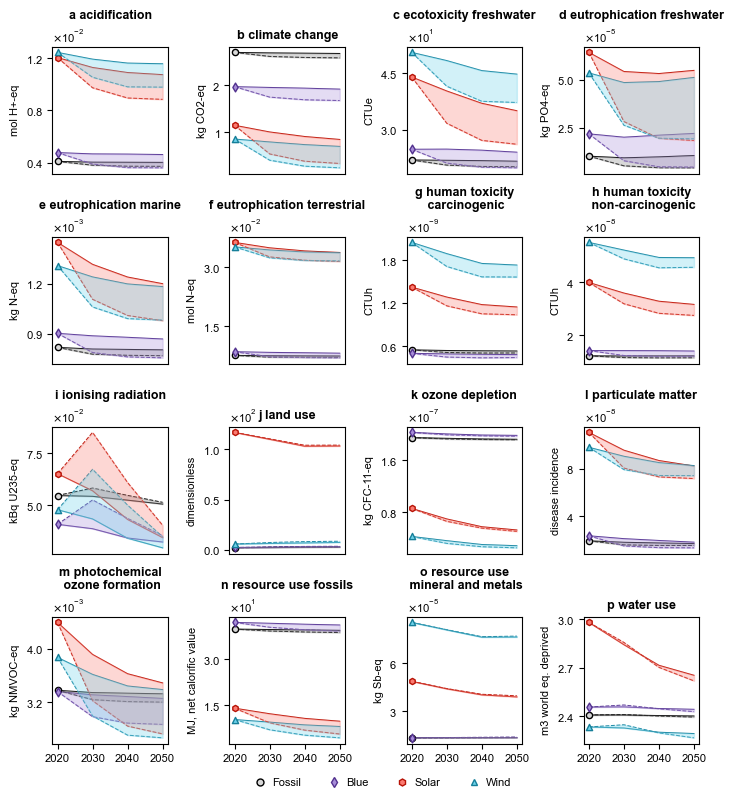

In [17]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ammoniaResult = ammoniaResults[impactCategories[i]]
    ammoniaResultsRCP6 = ammoniaResult[ammoniaResult['Database'].str.contains('Base')]
    ammoniaBAURCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('solar')]

    ammoniaResultsRCP19 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP19')]
    ammoniaBAURCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('solar')]

    ammoniaBAURCP6 = ammoniaBAURCP6.reset_index(drop=True)
    ammoniaBlueRCP6 = ammoniaBlueRCP6.reset_index(drop=True)
    ammoniaWindRCP6 = ammoniaWindRCP6.reset_index(drop = True)
    ammoniaSolarRCP6 = ammoniaSolarRCP6.reset_index(drop = True)

    ammoniaBAURCP19 = ammoniaBAURCP19.reset_index(drop=True)
    ammoniaBlueRCP19 = ammoniaBlueRCP19.reset_index(drop=True)
    ammoniaWindRCP19 = ammoniaWindRCP19.reset_index(drop = True)
    ammoniaSolarRCP19 = ammoniaSolarRCP19.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, ammoniaBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ammoniaBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, ammoniaBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, ammoniaSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, ammoniaWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, ammoniaBAURCP6['Impact'], ammoniaBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ammoniaBlueRCP6['Impact'], ammoniaBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ammoniaSolarRCP6['Impact'], ammoniaSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ammoniaWindRCP6['Impact'], ammoniaWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], ammoniaBAURCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ammoniaBlueRCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ammoniaSolarRCP6['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ammoniaWindRCP6['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

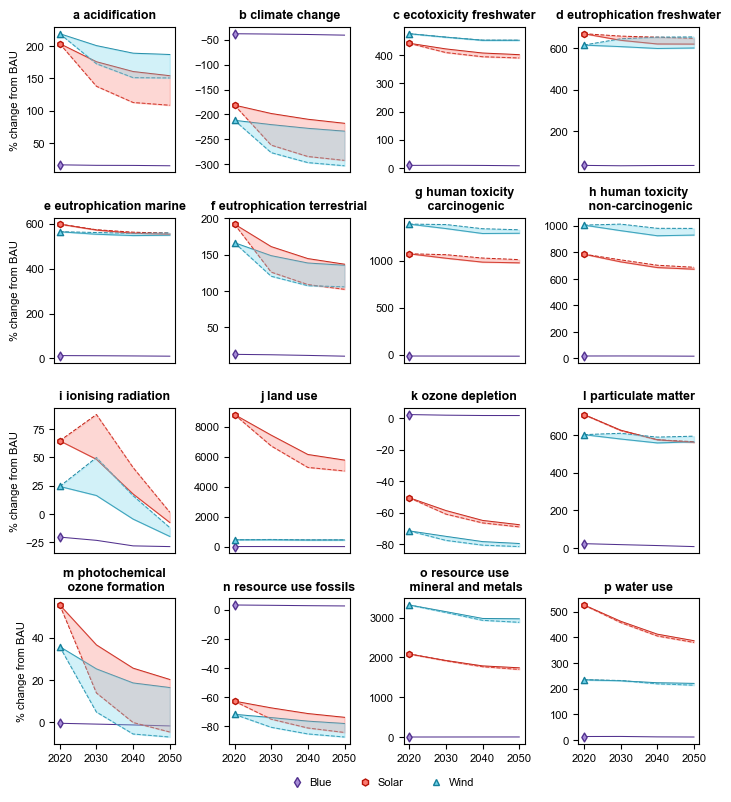

In [18]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    methanolResult = methanolResults[impactCategories[i]]
    methanolResultsRCP6 = methanolResult[methanolResult['Database'].str.contains('Base')]
    methanolBAURCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, blue')]
    methanolWindRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolResultsRCP19 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP19')]
    methanolBAURCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('ammoni, blue')]
    methanolWindRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolBAURCP6 = methanolBAURCP6.reset_index(drop=True)
    methanolBlueRCP6 = methanolBlueRCP6.reset_index(drop=True)
    methanolWindRCP6 = methanolWindRCP6.reset_index(drop = True)
    methanolSolarRCP6 = methanolSolarRCP6.reset_index(drop = True)
    blueRCP6 = (methanolBlueRCP6['Impact'] - methanolBAURCP6['Impact'])/methanolBAURCP6['Impact']*100
    windRCP6 = (methanolWindRCP6['Impact'] - methanolBAURCP6['Impact'])/methanolBAURCP6['Impact']*100
    solarRCP6 = (methanolSolarRCP6['Impact'] - methanolBAURCP6['Impact'])/methanolBAURCP6['Impact']*100

    methanolBAURCP19 = methanolBAURCP19.reset_index(drop=True)
    methanolBlueRCP19 = methanolBlueRCP19.reset_index(drop=True)
    methanolWindRCP19 = methanolWindRCP19.reset_index(drop = True)
    methanolSolarRCP19 = methanolSolarRCP19.reset_index(drop = True)
    blueRCP19 = (methanolBlueRCP19['Impact'] - methanolBAURCP19['Impact'])/methanolBAURCP19['Impact']*100
    windRCP19 = (methanolWindRCP19['Impact'] - methanolBAURCP19['Impact'])/methanolBAURCP19['Impact']*100
    solarRCP19 = (methanolSolarRCP19['Impact'] - methanolBAURCP19['Impact'])/methanolBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol relative image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol relative image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

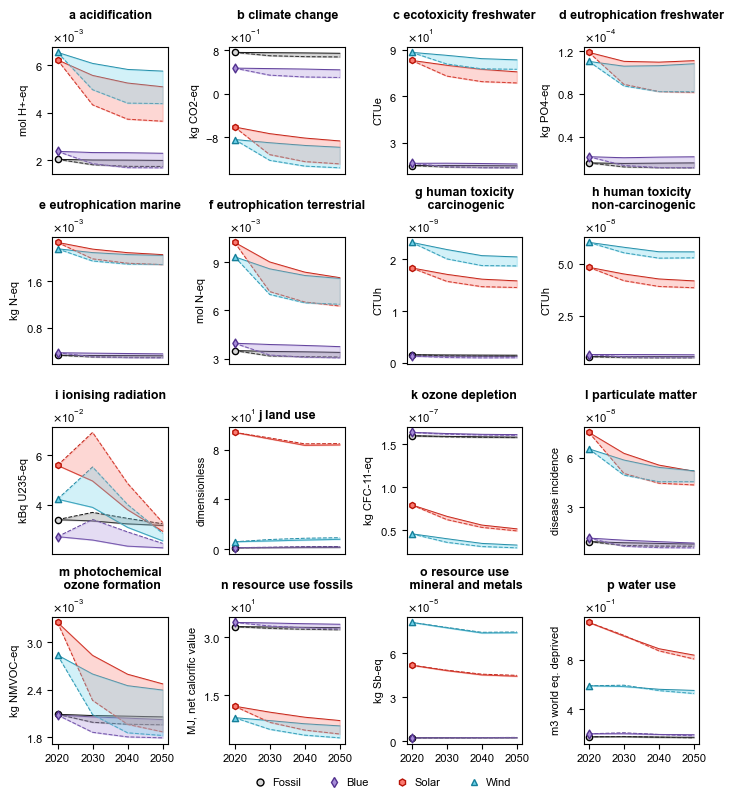

In [19]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    methanolResult = methanolResults[impactCategories[i]]
    methanolResultsRCP6 = methanolResult[methanolResult['Database'].str.contains('Base')]
    methanolBAURCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, blue')]
    methanolWindRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolResultsRCP19 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP19')]
    methanolBAURCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, blue')]
    methanolWindRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolBAURCP6 = methanolBAURCP6.reset_index(drop=True)
    methanolBlueRCP6 = methanolBlueRCP6.reset_index(drop=True)
    methanolWindRCP6 = methanolWindRCP6.reset_index(drop = True)
    methanolSolarRCP6 = methanolSolarRCP6.reset_index(drop = True)

    methanolBAURCP19 = methanolBAURCP19.reset_index(drop=True)
    methanolBlueRCP19 = methanolBlueRCP19.reset_index(drop=True)
    methanolWindRCP19 = methanolWindRCP19.reset_index(drop = True)
    methanolSolarRCP19 = methanolSolarRCP19.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, methanolBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, methanolBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, methanolBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, methanolSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, methanolWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, methanolBAURCP6['Impact'], methanolBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, methanolBlueRCP6['Impact'], methanolBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, methanolSolarRCP6['Impact'], methanolSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, methanolWindRCP6['Impact'], methanolWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], methanolBAURCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], methanolBlueRCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], methanolSolarRCP6['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], methanolWindRCP6['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

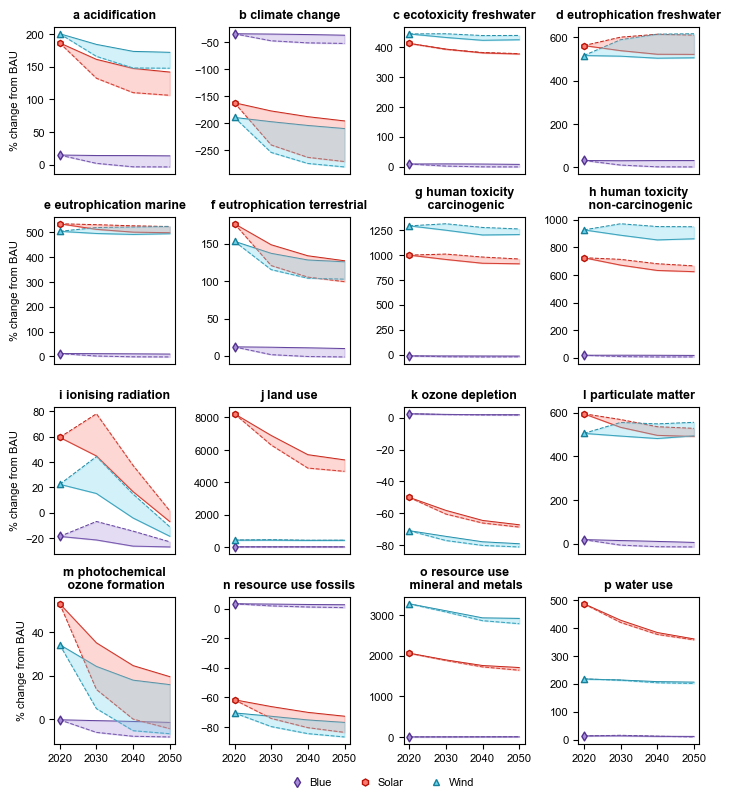

In [20]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ethyleneResult = ethyleneResults[impactCategories[i]]
    ethyleneResultsRCP6 = ethyleneResult[ethyleneResult['Database'].str.contains('Base')]
    ethyleneBAURCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneResultsRCP19 = ethyleneResult[ethyleneResult['Database'].str.contains('Base 2020') | ethyleneResult['Database'].str.contains('RCP19')]
    ethyleneBAURCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneBAURCP6 = ethyleneBAURCP6.reset_index(drop=True)
    ethyleneBlueRCP6 = ethyleneBlueRCP6.reset_index(drop=True)
    ethyleneWindRCP6 = ethyleneWindRCP6.reset_index(drop = True)
    ethyleneSolarRCP6 = ethyleneSolarRCP6.reset_index(drop = True)
    blueRCP6 = (ethyleneBlueRCP6['Impact'] - ethyleneBAURCP6['Impact'])/ethyleneBAURCP6['Impact']*100
    windRCP6 = (ethyleneWindRCP6['Impact'] - ethyleneBAURCP6['Impact'])/ethyleneBAURCP6['Impact']*100
    solarRCP6 = (ethyleneSolarRCP6['Impact'] - ethyleneBAURCP6['Impact'])/ethyleneBAURCP6['Impact']*100

    ethyleneBAURCP19 = ethyleneBAURCP19.reset_index(drop=True)
    ethyleneBlueRCP19 = ethyleneBlueRCP19.reset_index(drop=True)
    ethyleneWindRCP19 = ethyleneWindRCP19.reset_index(drop = True)
    ethyleneSolarRCP19 = ethyleneSolarRCP19.reset_index(drop = True)
    blueRCP19 = (ethyleneBlueRCP19['Impact'] - ethyleneBAURCP19['Impact'])/ethyleneBAURCP19['Impact']*100
    windRCP19 = (ethyleneWindRCP19['Impact'] - ethyleneBAURCP19['Impact'])/ethyleneBAURCP19['Impact']*100
    solarRCP19 = (ethyleneSolarRCP19['Impact'] - ethyleneBAURCP19['Impact'])/ethyleneBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene relative image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene relative image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

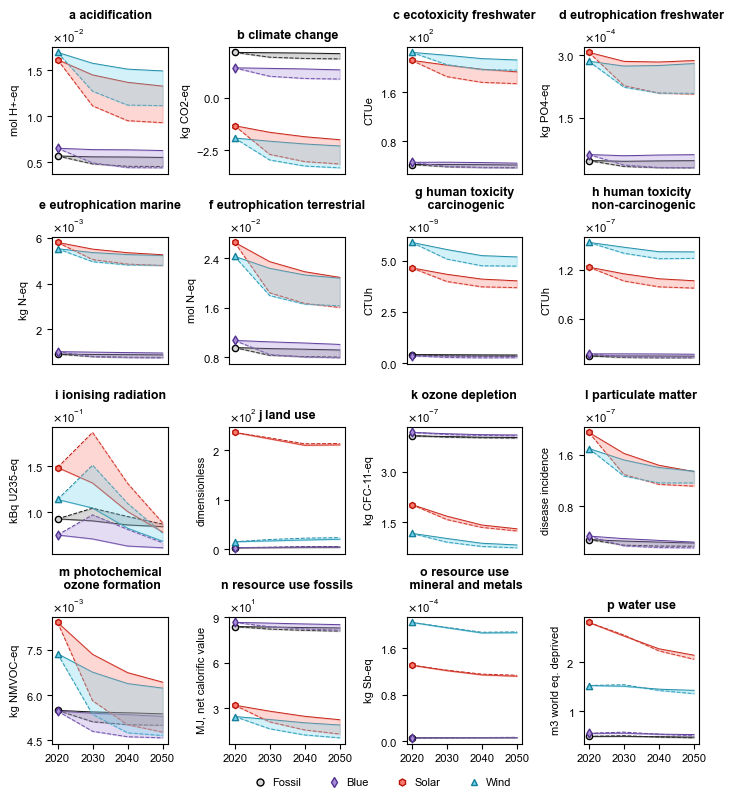

In [21]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ethyleneResult = ethyleneResults[impactCategories[i]]
    ethyleneResultsRCP6 = ethyleneResult[ethyleneResult['Database'].str.contains('Base')]
    ethyleneBAURCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneResultsRCP19 = ethyleneResult[ethyleneResult['Database'].str.contains('Base 2020') | ethyleneResult['Database'].str.contains('RCP19')]
    ethyleneBAURCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneBAURCP6 = ethyleneBAURCP6.reset_index(drop=True)
    ethyleneBlueRCP6 = ethyleneBlueRCP6.reset_index(drop=True)
    ethyleneWindRCP6 = ethyleneWindRCP6.reset_index(drop = True)
    ethyleneSolarRCP6 = ethyleneSolarRCP6.reset_index(drop = True)

    ethyleneBAURCP19 = ethyleneBAURCP19.reset_index(drop=True)
    ethyleneBlueRCP19 = ethyleneBlueRCP19.reset_index(drop=True)
    ethyleneWindRCP19 = ethyleneWindRCP19.reset_index(drop = True)
    ethyleneSolarRCP19 = ethyleneSolarRCP19.reset_index(drop = True)

    ax[i // 4, i % 4].plot(years, ethyleneBAURCP6['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ethyleneBlueRCP6['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ethyleneSolarRCP6['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ethyleneWindRCP6['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, ethyleneBAURCP19['Impact'], label = 'Fossil', color = 'black', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, ethyleneBlueRCP19['Impact'], label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, ethyleneSolarRCP19['Impact'], label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, ethyleneWindRCP19['Impact'], label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, ethyleneBAURCP6['Impact'], ethyleneBAURCP19['Impact'], color = '#808080', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ethyleneBlueRCP6['Impact'], ethyleneBlueRCP19['Impact'], color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ethyleneSolarRCP6['Impact'], ethyleneSolarRCP19['Impact'], color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, ethyleneWindRCP6['Impact'], ethyleneWindRCP19['Impact'], color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], ethyleneBAURCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'o', facecolor = '#d8d8d8', edgecolors = 'black', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ethyleneBlueRCP6['Impact'][0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ethyleneSolarRCP6['Impact'][0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], ethyleneWindRCP6['Impact'][0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

    ax[i // 4, i % 4].yaxis.set_major_locator(MaxNLocator(nbins = 3))
    ax[i // 4, i % 4].set_ylabel(units[i])
    ax[i // 4, i % 4].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText = True))
    ax[i // 4, i % 4].ticklabel_format(axis = 'y', style = 'sci', scilimits = (0, 0))

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "black",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene absolute image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene absolute image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')